# Exploring decisions
It will help better understand those PDFs and do better chunking and single RAG

## Imports and paths

In [12]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pdfplumber # Great for inspecting PDF layout
from pathlib import Path
from tqdm import tqdm # Shows progress bar

# style for charts
sns.set_theme(style="whitegrid")

# define project paths based on your structure
BASE_DIR = Path('..') 
RAW_DATA_DIR = BASE_DIR / 'data' / '01_raw_pdfs'

print(f"Looking for data in: {RAW_DATA_DIR.resolve()}")

Looking for data in: /Users/stefanec/STU_FIIT/bachelor-thesis-legal-text-information-extraction/data/01_raw_pdfs


## Load file registry

In [15]:
records = []


# structure: 01_raw_pdfs / {case_folder} / {file}.pdf
pdf_files = list(RAW_DATA_DIR.rglob("*.pdf"))

print(f"Found {len(pdf_files)} PDF files. Processing metadata...")

for pdf_path in tqdm(pdf_files):
    folder = pdf_path.parent
    
    # trying to find the corresponding JSON metadata file
    json_files = list(folder.glob("*.json"))
    
    metadata = {}
    if json_files:
        try:
            with open(json_files[0], 'r', encoding='utf-8') as f:
                metadata = json.load(f)
        except Exception as e:
            print(f"Error reading JSON for {pdf_path.name}: {e}")

    # --- EXTRACTING FIELDS BASED ON  JSON STRUCTURE ---
    
    # 1. gett court name (is nested inside 'sud' -> 'nazov')
    court_info = metadata.get('sud', {})
    court_name = court_info.get('nazov', 'Unknown')
    
    # 2. get date (format is dd.mm.yyyy)
    raw_date = metadata.get('datumVydania', None)
    
    # 3. get Case ID (Spisová značka)
    case_id = metadata.get('spisovaZnacka', folder.name)
    
    # 4. get decision type (Rozsudok vs Uznesenie)
    #  might be list or string, handle both
    decision_form = metadata.get('formaRozhodnutia', 'Unknown')
    
    # 5. get ECLI (Unique ID)
    ecli = metadata.get('ecli', 'N/A')

    # creating  record
    record = {
        'filename': pdf_path.name,
        'rel_path': str(pdf_path.relative_to(BASE_DIR)),
        'file_size_kb': round(pdf_path.stat().st_size / 1024, 2),
        'court': court_name, 
        'date_str': raw_date, # keeping string for now
        'case_id': case_id,
        'type': decision_form,
        'ecli': ecli,
        'raw_metadata': metadata # storing also full json just to be sure
    }
    records.append(record)

# convert to DataFrame
df = pd.DataFrame(records)

# convert date column to datetime objects ( format dd.mm.yyyy)
# dayfirst=True
df['date'] = pd.to_datetime(df['date_str'], format='%d.%m.%Y', errors='coerce', dayfirst=True)

print(f"Loaded dataframe with {len(df)} rows.")

# show sample
display(df[['case_id', 'court', 'date', 'type']].head())

Found 176 PDF files. Processing metadata...


100%|██████████| 176/176 [00:00<00:00, 5741.91it/s]

✅ Loaded dataframe with 176 rows.


,case_id,court,date,type
0,35Cbi/59/2006,Krajský súd v Banskej Bystrici,2012-06-04,Rozsudok
1,43Cob/53/2023,Krajský súd v Banskej Bystrici,2023-08-07,Rozsudok
2,43Cob/20/2016,Krajský súd v Banskej Bystrici,2016-03-10,Rozsudok
3,43CoE/215/2015,Krajský súd v Banskej Bystrici,2015-05-28,Uznesenie
4,42Cob/94/2024,Krajský súd v Banskej Bystrici,2025-09-09,Rozsudok


## PDF quality - smoke test

In [17]:
def check_pdf_text_quality(pdf_path):
    """
    Opens a PDF and tries to extract text from the first page.
    Returns the text length and a snippet.
    """
    try:
        with pdfplumber.open(pdf_path) as pdf:
            if not pdf.pages:
                return 0, "EMPTY_FILE"
            
            first_page_text = pdf.pages[0].extract_text()
            if not first_page_text:
                return 0, "NO_TEXT_FOUND (Scanned?)"
            
            return len(first_page_text), first_page_text[:200].replace('\n', ' ')
    except Exception as e:
        return 0, f"Error: {str(e)}"

# Apply this check to a sample of 5 documents
sample_df = df.head(10).copy()
print("Inspecting first 10 documents for text content...")

results = []
for _, row in sample_df.iterrows():
    full_path = BASE_DIR / row['rel_path']
    length, snippet = check_pdf_text_quality(full_path)
    results.append({'filename': row['filename'], 'text_len': length, 'snippet': snippet})

pd.DataFrame(results)

🕵️ Inspecting first 10 documents for text content...


,filename,text_len,snippet
0,00_dokument.pdf,3336,Súd: Krajský súd Banská Bystrica Spisová značk...
1,00_dokument.pdf,3084,Súd: Krajský súd Banská Bystrica Spisová značk...
2,00_dokument.pdf,3206,Súd: Krajský súd Banská Bystrica Spisová značk...
3,00_dokument.pdf,3456,Súd: Krajský súd Banská Bystrica Spisová značk...
4,00_dokument.pdf,3053,Súd: Krajský súd Banská Bystrica Spisová značk...
5,00_dokument.pdf,2971,Súd: Krajský súd Banská Bystrica Spisová značk...
6,00_dokument.pdf,3231,Súd: Krajský súd Banská Bystrica Spisová značk...
7,00_dokument.pdf,3094,Súd: Krajský súd Banská Bystrica Spisová značk...
8,00_dokument.pdf,3348,Súd: Krajský súd Banská Bystrica Spisová značk...
9,00_dokument.pdf,3263,Súd: Krajský súd Banská Bystrica Spisová značk...


## Text statistics

In [18]:
# Lets extract page counts for ALL files
page_counts = []
total_chars = []

print("---- Calculating statistics (this might take a moment if more pdfs ) ---")

for _, row in tqdm(df.iterrows(), total=len(df)):
    full_path = BASE_DIR / row['rel_path']
    try:
        with pdfplumber.open(full_path) as pdf:
            num_pages = len(pdf.pages)
            # rapid extraction for stats
            text = "".join([p.extract_text() or "" for p in pdf.pages]) 
            
            page_counts.append(num_pages)
            total_chars.append(len(text))
    except:
        page_counts.append(0)
        total_chars.append(0)

df['page_count'] = page_counts
df['char_count'] = total_chars

# Estimate tokens ( Roughly 1 token ~= 4 chars )
df['est_tokens'] = (df['char_count'] / 4).astype(int)

# show summary statistics
print("\n--- Dataset Statistics ---")
print(df[['page_count', 'char_count', 'est_tokens']].describe().round(1))

📊 Calculating statistics (this might take a moment)...


100%|██████████| 176/176 [02:11<00:00,  1.34it/s]


--- 📈 Dataset Statistics ---
       page_count  char_count  est_tokens
count       176.0       176.0       176.0
mean          7.9     33701.3      8424.9
std           4.4     22184.9      5546.2
min           2.0      6613.0      1653.0
25%           5.0     18899.0      4724.2
50%           6.5     25454.0      6363.0
75%          10.0     42541.2     10635.2
max          26.0    126332.0     31583.0


## Visualizing the Dataset

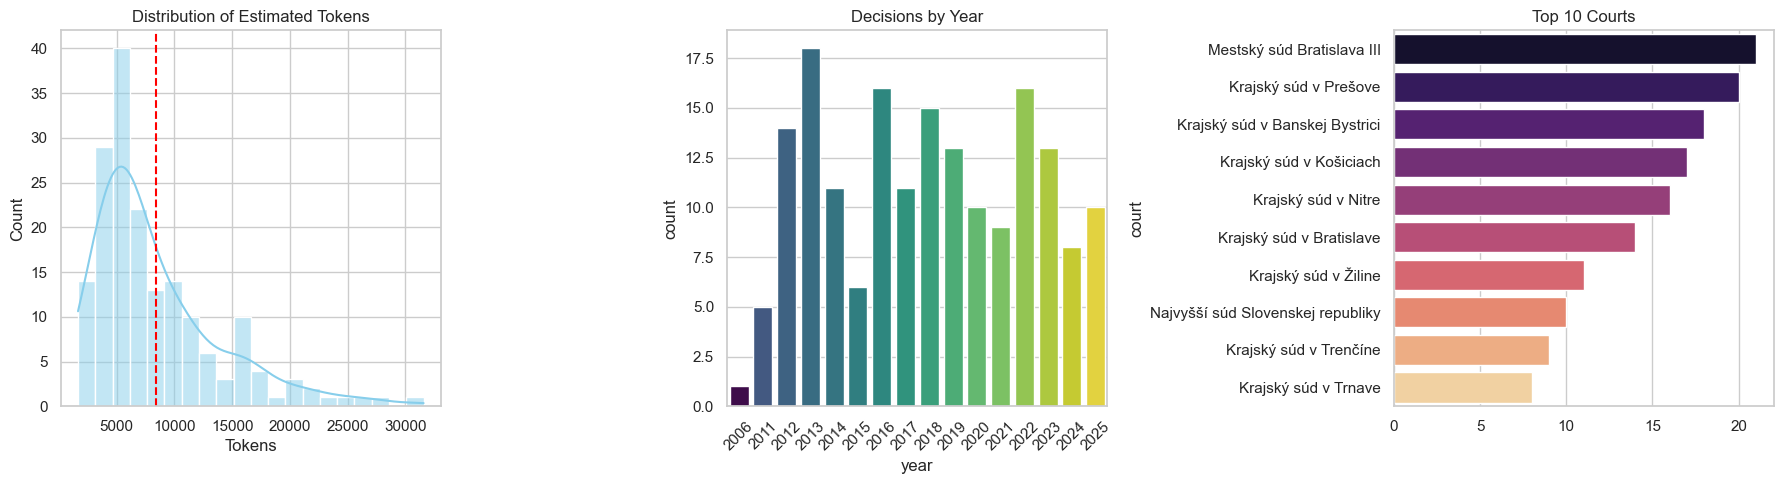

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution of tokens (how expensive will the LLM be?)
sns.histplot(df['est_tokens'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Estimated Tokens')
axes[0].set_xlabel('Tokens')
axes[0].axvline(df['est_tokens'].mean(), color='red', linestyle='--', label='Mean')

# 2. distribution of years (temporal coverage)
if df['date'].notna().sum() > 0:
    df['year'] = df['date'].dt.year
    years = df['year'].dropna().astype(int)

    sns.countplot(
        x=years,
        hue=years,            
        palette='viridis',
        ax=axes[1],
        legend=False          
    )
    axes[1].set_title('Decisions by year')
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].text(0.5, 0.5, 'No dates found in metadata', ha='center')

# 3. top courts (Where does data come from?)
top_courts = df['court'].value_counts().head(10)
sns.barplot(
    x=top_courts.values,
    y=top_courts.index,
    hue=top_courts.index,       
    palette='magma',
    ax=axes[2],
    legend=False             
)
axes[2].set_title('Top 10 Courts')

plt.tight_layout()
plt.show()


## Deep Dive into ONE Document

In [21]:
# Find the specific sample file
sample_file_name = "00_dokument.pdf" # or whatever is file named
sample_row = df[df['filename'] == sample_file_name]

if not sample_row.empty:
    path = BASE_DIR / sample_row.iloc[0]['rel_path']
    
    with pdfplumber.open(path) as pdf:
        print(f"Analyzing: {sample_file_name}")
        print(f"Total pages: {len(pdf.pages)}")
        
        # Display Page 1 Layout
        p1 = pdf.pages[0]
        text = p1.extract_text()
        
        print("\n--- HEADER ANALYSIS (First 500 chars) ---")
        print(text[:500])
        
        print("\n--- SEARCHING FOR PARAGRAPH STRUCTURE ---")
        # checking if we can see the numbered paragraphs (1., 11., etc.)
        lines = text.split('\n')
        for line in lines:
            if line.strip().startswith(('1.', '11.', '12.', 'Súd:')):
                print(f"Found structure: {line}")
else:
    print("Sample file not found in the index. Check the filename.")

Analyzing: 00_dokument.pdf
Total pages: 6

--- HEADER ANALYSIS (First 500 chars) ---
Súd: Krajský súd Banská Bystrica
Spisová značka: 35Cbi/59/2006
Identifikačné číslo súdneho spisu: 6006201162
Dátum vydania rozhodnutia: 04. 06. 2012
Meno a priezvisko sudcu, VSÚ: JUDr. Miroslava Púchovská
ECLI: ECLI:SK:KSBB:2012:6006201162.14
ROZSUDOK V MENE
SLOVENSKEJ REPUBLIKY
Krajský súd v Banskej Bystrici JUDr. Miroslavou Púchovskou v právnej veci navrhovateľky ADRIA PLUS,
s. r. o., Podhora č. 48, 034 01 Ružomberok, IČO:36 439 126, zastúpenej advokátom JUDr. Jozefom
Uličným so sídlom Likavka

--- SEARCHING FOR PARAGRAPH STRUCTURE ---
Found structure: Súd: Krajský súd Banská Bystrica
